In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from get_train_test import TrainTestBuilder

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, accuracy_score, confusion_matrix, classification_report, roc_curve, auc, f1_score, confusion_matrix, ConfusionMatrixDisplay, silhouette_score
from sklearn.calibration import calibration_curve

In [3]:
all_numerical_feats = [
    "td_defense_pct_red", "td_total_attempted_against_red", "td_total_landed_against_red",
    "td_defense_pct_blue", "td_total_attempted_against_blue", "td_total_landed_against_blue",
    "sig_str_defense_pct_red", "sig_str_total_attempted_against_red", "sig_str_total_landed_against_red",
    "sig_str_defense_pct_blue", "sig_str_total_attempted_against_blue", "sig_str_total_landed_against_blue",
    "td_accuracy_pct_red", "td_accuracy_pct_blue", "sig_str_accuracy_pct_red", "sig_str_accuracy_pct_blue",
    "kd_pm_red", "kd_total_red", "kd_pm_blue", "kd_total_blue",
    "sig_str_landed_pm_red", "sig_str_landed_total_red", "sig_str_landed_pm_blue", "sig_str_landed_total_blue",
    "sig_str_absorbed_pm_red", "sig_str_absorbed_total_red", "sig_str_absorbed_pm_blue", "sig_str_absorbed_total_blue",
    "sig_str_attempted_pm_red", "sig_str_attempted_total_red", "sig_str_attempted_pm_blue", "sig_str_attempted_total_blue",
    "leg_str_pm_red", "leg_str_total_red", "leg_str_pm_blue", "leg_str_total_blue",
    "head_str_pm_red", "head_str_total_red", "head_str_pm_blue", "head_str_total_blue",
    "body_str_pm_red", "body_str_total_red", "body_str_pm_blue", "body_str_total_blue",
    "clinch_str_pm_red", "clinch_str_total_red", "clinch_str_pm_blue", "clinch_str_total_blue",
    "td_landed_pm_red", "td_landed_total_red", "td_landed_pm_blue", "td_landed_total_blue",
    "td_attempted_pm_red", "td_attempted_total_red", "td_attempted_pm_blue", "td_attempted_total_blue",
    "td_defended_pm_red", "td_defended_total_red", "td_defended_pm_blue", "td_defended_total_blue",
    "control_pm_red", "control_total_red", "control_pm_blue", "control_total_blue",
    "sub_att_pm_red", "sub_att_total_red", "sub_att_pm_blue", "sub_att_total_blue",
    "reverse_pm_red", "reverse_total_red", "reverse_pm_blue", "reverse_total_blue",
    "total_fight_time_red", "total_fight_time_blue",
    "age_red", "age_blue", "height_red", "height_blue", "reach_red", "reach_blue",
    "kd_total_diff", "kd_pm_diff", "sig_str_landed_total_diff", "sig_str_landed_pm_diff",
    "sig_str_absorbed_total_diff", "sig_str_absorbed_pm_diff", "sig_str_attempted_total_diff",
    "sig_str_attempted_pm_diff", "leg_str_total_diff", "leg_str_pm_diff",
    "head_str_total_diff", "head_str_pm_diff", "body_str_total_diff", "body_str_pm_diff",
    "clinch_str_total_diff", "clinch_str_pm_diff", "td_landed_total_diff", "td_landed_pm_diff",
    "td_attempted_total_diff", "td_attempted_pm_diff", "control_total_diff", "control_pm_diff",
    "sub_att_total_diff", "sub_att_pm_diff", "reverse_total_diff", "reverse_pm_diff",
    "age_diff", "height_diff", "reach_diff", "sig_str_defense_pct_diff", "sig_str_accuracy_pct_diff",
    "td_accuracy_pct_diff", "td_defense_pct_diff", "avg_fight_min_red", "avg_fight_min_blue",
    "avg_fight_min_diff", "total_bonus_red", "total_bonus_blue", "total_bonus_diff",
    "elo_red", "elo_blue", "elo_red_proba", "elo_blue_proba", "elo_diff",
    "glicko_red", "glicko_blue", "glicko_rd_red", "glicko_rd_blue", "glicko_proba_red",
    "glicko_proba_blue", "glicko_diff", "months_since_red", "months_since_blue", "months_since_diff",
    "win_streak_red", "lose_streak_red", "win_streak_blue", "lose_streak_blue",
    "win_pct_red", "win_pct_blue", "num_fights_red", "num_fights_blue", "num_wins_red", "num_wins_blue",
    "num_losses_red", "num_losses_blue", "num_fights_diff", "win_streak_diff", "lose_streak_diff",
    "wins_diff", "losses_diff", "win_pct_diff",
    "decision_wins_red", "ko_wins_red", "sub_wins_red", "decision_wins_blue", "ko_wins_blue", "sub_wins_blue",
    "decision_wins_diff", "ko_wins_diff", "sub_wins_diff", "decision_losses_red", "ko_losses_red",
    "sub_losses_red", "decision_losses_blue", "ko_losses_blue", "sub_losses_blue",
    "decision_losses_diff", "ko_losses_diff", "sub_losses_diff",
    "max_elo_win_red", "max_elo_win_blue", "max_glicko_win_red", "max_glicko_win_blue",
    "ko_pct_red", "dec_pct_red", "sub_pct_red", "ko_pct_blue", "dec_pct_blue", "sub_pct_blue",
    "ko_pct_diff", "dec_pct_diff", "sub_pct_diff",
    "ratio_td_red", "ratio_td_blue", "ratio_control_red", "ratio_control_blue",
    "ratio_sigstrike_red", "ratio_sigstrike_blue", "ratio_td_diff", "ratio_control_diff", "ratio_sigstrike_diff",
    "red_title_fights", "blue_title_fights", "red_title_wins", "blue_title_wins",
    "red_title_losses", "blue_title_losses", "red_title_win_pct", "blue_title_win_pct",
    "fav_counts_red", "dog_counts_red", "fav_counts_blue", "dog_counts_blue",
    "fav_counts_diff", "dog_counts_diff"
]


non_feats = [
    'date','event_date','event_location','fighter_blue','fighter_red',
    'method','og_blue_name','og_red_fighter', 'red_fighter_stats', 'blue_fighter_stats',
    'pimp_close1_blue','pimp_close1_red','pimp_close2_blue','pimp_close2_red',
    'juice_close1_blue','juice_close1_red','juice_close2_blue','juice_close2_red',
    'line_movement_close1_blue','line_movement_close1_red','line_movement_close2_blue','line_movement_close2_red',
    'winner_name',
    
    'red_fighter_odds','blue_fighter_odds',
    'dec_close1_blue','dec_close1_red','dec_close2_blue','dec_close2_red',
    'dec_fair_close1_blue','dec_fair_close1_red','dec_fair_close2_blue','dec_fair_close2_red',
    'red_ud_to_fav_close1','red_ud_to_fav_close2','blue_ud_to_fav_close1','blue_ud_to_fav_close2',
    'red_stayed_fav_close1','red_stayed_fav_close2','blue_stayed_fav_close1','blue_stayed_fav_close2',
    'red_fav_to_ud_close1','red_fav_to_ud_close2','blue_fav_to_ud_close1','blue_fav_to_ud_close2',
    'red_stayed_dog_close1','red_stayed_dog_close2','blue_stayed_dog_close1','blue_stayed_dog_close2',
    'proba_fair_close1_red','proba_fair_close1_blue','proba_fair_close2_red','proba_fair_close2_blue',
    'performance_bonus_winner', 'fight_otn_bonus', 'close1_blue','close1_red', 'close2_blue', 'close2_red'
]


In [4]:
def run_pca_with_plots(df_, features, variance_threshold=0.95, top_n=5):
    """
    Perform PCA on selected numerical features, display scree plot and biplot.
    Biplot shows only top_n features with the largest magnitude in PC1/PC2 space.
    
    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    features : list of str
        Numerical columns to include in PCA.
    variance_threshold : float, default=0.95
        Proportion of variance to retain.
    top_n : int, default=5
        Number of feature vectors to display on the biplot.
        
    Returns
    -------
    pca : sklearn.decomposition.PCA object
        Fitted PCA object.
    X_pca : np.ndarray
        Transformed PCA components.
    """
    # Extract and standardize numerical features
    df = df_.dropna().copy()
    print('PREPARE SHAPE:', df.shape)
    df = df[df['winner'] != 2]

    X = df[features].copy()
    X_scaled = StandardScaler().fit_transform(X)
    
    # Fit PCA
    pca = PCA(n_components=variance_threshold)
    X_pca = pca.fit_transform(X_scaled)

    print(f"Number of components retained to explain {variance_threshold*100:.1f}% variance: {X_pca.shape[1]}")
    print("Explained variance ratio per component:")
    print(pca.explained_variance_ratio_)

    # -----------------------
    # Scree Plot
    # -----------------------
    plt.figure(figsize=(8,5))
    plt.plot(np.arange(1, len(pca.explained_variance_ratio_)+1),
            pca.explained_variance_ratio_, 'o-', color='blue')
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance Ratio')
    plt.title('Scree Plot')
    plt.grid(True)
    plt.show()

    # -----------------------
    # Biplot (first 2 components, vectors only)
    # -----------------------
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5, color='grey')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA Biplot (Vectors Only)')

    # Compute vector magnitudes for each feature in PC1/PC2 space
    loadings = pca.components_[:2, :].T  # shape: (n_features, 2)

    # Plot all feature vectors
    for i in range(loadings.shape[0]):
        plt.arrow(0, 0, loadings[i,0]*max(X_pca[:,0]), loadings[i,1]*max(X_pca[:,1]), 
                color='red', alpha=0.7)

    plt.grid(True)
    plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
    plt.axvline(0, color='black', linestyle='--', linewidth=0.5)
    plt.show()

    return pca, X_pca

def pca_feature_magnitudes(df_, features, variance_threshold=0.95):
    """
    Perform PCA on selected features and return a DataFrame with
    the magnitude of each feature vector in the first two components.
    
    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame
    features : list of str
        Columns to use in PCA
    variance_threshold : float
        Fraction of variance to retain (for number of components)
    
    Returns
    -------
    pd.DataFrame
        Columns: ['feature', 'magnitude'], sorted descending by magnitude
    """

    df = df_.dropna().copy()
    print('PREPARE SHAPE:', df.shape)
    df = df[df['winner'] != 2]

    X = df[features].copy()
    X_scaled = StandardScaler().fit_transform(X)
    
    pca = PCA(n_components=variance_threshold)
    pca.fit(X_scaled)
    
    # Take first 2 components
    loadings = pca.components_[:2, :].T  # shape: (n_features, 2)
    
    # Compute magnitude for each feature vector
    magnitudes = np.linalg.norm(loadings, axis=1)
    
    df_magnitude = pd.DataFrame({
        'feature': features,
        'magnitude': magnitudes
    }).sort_values('magnitude', ascending=False).reset_index(drop=True)
    
    return df_magnitude




PREPARE SHAPE: (5118, 290)
Number of components retained to explain 95.0% variance: 74
Explained variance ratio per component:
[0.15089952 0.12992937 0.0470027  0.04206365 0.03213136 0.03106813
 0.02867332 0.02538139 0.0239458  0.01844576 0.01677868 0.01609425
 0.01533595 0.01394489 0.0135318  0.01268191 0.01208832 0.0115571
 0.0111314  0.0102675  0.01002128 0.00981938 0.0095985  0.00944122
 0.0090622  0.00887875 0.00879511 0.00853351 0.00814584 0.00775718
 0.0076531  0.00739934 0.0071265  0.00689419 0.00683205 0.00663946
 0.00644544 0.00633185 0.0061894  0.00582573 0.00557834 0.00546426
 0.00540203 0.00529632 0.0051836  0.00508319 0.00494451 0.00479838
 0.00474505 0.00471864 0.0046492  0.00448045 0.00444636 0.00441455
 0.00427467 0.00396217 0.00392389 0.00382154 0.00369751 0.00361917
 0.00357941 0.00332627 0.00319444 0.00308323 0.00299071 0.00284173
 0.00275405 0.00268661 0.00264042 0.00259326 0.00250374 0.00235217
 0.00234239 0.00228932]


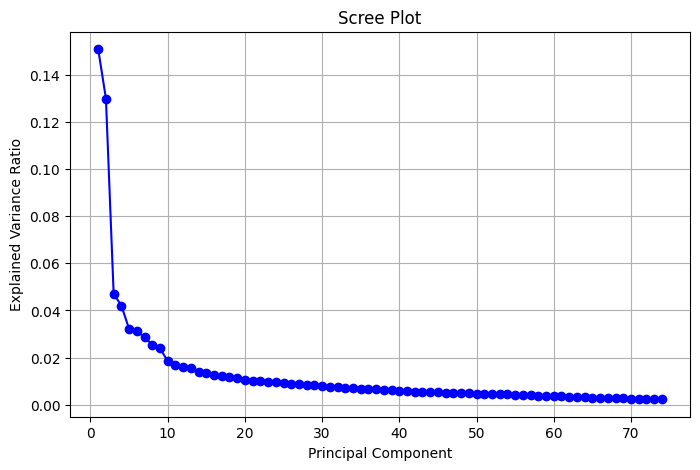

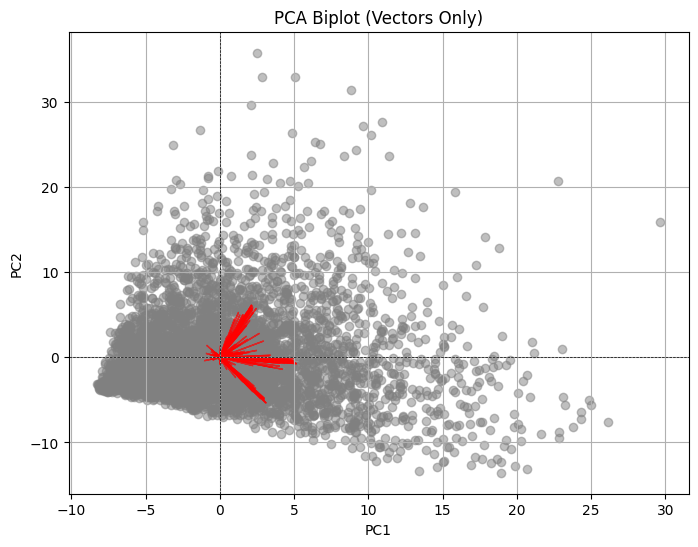

PREPARE SHAPE: (5118, 290)


In [5]:

fp = r'C:\Users\jcmar\my_files\SportsBetting\data\entire_odds_stats_2025-12-04.csv'
df_model = pd.read_csv(fp)
_,_=run_pca_with_plots(df_model, all_numerical_feats)

df_mag = pca_feature_magnitudes(df_model, all_numerical_feats)

In [6]:
df_mag.head(50)

,feature,magnitude
0,total_fight_time_blue,0.186110
1,avg_fight_min_blue,0.185648
2,num_fights_blue,0.184942
3,avg_fight_min_diff,0.183286
4,num_fights_diff,0.182505
5,td_defended_total_blue,0.180885
6,num_wins_blue,0.180675
7,sig_str_total_landed_against_blue,0.176868
8,sig_str_landed_total_blue,0.176318
9,sig_str_total_attempted_against_blue,0.175848


In [5]:
fp = r'C:\Users\jcmar\my_files\SportsBetting\data\entire_odds_stats_2025-12-04.csv'
df_model = pd.read_csv(fp)

selected_feats = all_numerical_feats
y = 'winner'
builder = TrainTestBuilder(df=df_model, target_col=y, non_features=non_feats, train_size=0.8, random_state=42)
builder.filter_by_year(2010, date_col='event_date')
X_train, X_test, y_train, y_test, df_train, df_test = builder.prepare_train_test(selected_feats, clustering=False)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)




Filtered: kept 6577 rows from year 2010 onward.
PREPARE SHAPE: (4830, 290)
MODEL SHAPE: (4743, 290)
Categorical columns: []
Numerical columns: ['td_defense_pct_red', 'td_total_attempted_against_red', 'td_total_landed_against_red', 'td_defense_pct_blue', 'td_total_attempted_against_blue', 'td_total_landed_against_blue', 'sig_str_defense_pct_red', 'sig_str_total_attempted_against_red', 'sig_str_total_landed_against_red', 'sig_str_defense_pct_blue', 'sig_str_total_attempted_against_blue', 'sig_str_total_landed_against_blue', 'td_accuracy_pct_red', 'td_accuracy_pct_blue', 'sig_str_accuracy_pct_red', 'sig_str_accuracy_pct_blue', 'kd_pm_red', 'kd_total_red', 'kd_pm_blue', 'kd_total_blue', 'sig_str_landed_pm_red', 'sig_str_landed_total_red', 'sig_str_landed_pm_blue', 'sig_str_landed_total_blue', 'sig_str_absorbed_pm_red', 'sig_str_absorbed_total_red', 'sig_str_absorbed_pm_blue', 'sig_str_absorbed_total_blue', 'sig_str_attempted_pm_red', 'sig_str_attempted_total_red', 'sig_str_attempted_pm_blu

In [7]:
X_train.isna().sum()

td_defense_pct_red                 0
td_total_attempted_against_red     0
td_total_landed_against_red        0
td_defense_pct_blue                0
td_total_attempted_against_blue    0
                                  ..
dog_counts_red                     0
fav_counts_blue                    0
dog_counts_blue                    0
fav_counts_diff                    0
dog_counts_diff                    0
Length: 206, dtype: int64

In [12]:
def pca_logit_eval(X_train, X_test, y_train, y_test, variance_threshold=0.95, n_components=None):
    """
    Fit PCA on train set, transform both train and test, fit logistic regression (Logit),
    and compute accuracy and Brier score for train and test sets.
    
    Parameters
    ----------
    X_train : pd.DataFrame
        Training features (numerical)
    X_test : pd.DataFrame
        Test features (numerical)
    y_train : pd.Series or np.array
        Binary target for training
    y_test : pd.Series or np.array
        Binary target for testing
    variance_threshold : float
        Fraction of variance to retain in PCA if n_components is None (default 0.95)
    n_components : int or None
        Number of principal components to keep. Overrides variance_threshold if provided.
    
    Returns
    -------
    dict with keys: train_acc, test_acc, train_brier, test_brier, model, pca, scaler
    """
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    
    # Fit PCA on train set
    if n_components is not None:
        pca = PCA(n_components=n_components)
    else:
        pca = PCA(n_components=variance_threshold)
        
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca  = pca.transform(X_test_scaled)
    
    # Add constant for statsmodels
    X_train_sm = sm.add_constant(X_train_pca)
    X_test_sm  = sm.add_constant(X_test_pca)
    
    # Fit logit model
    logit_model = sm.Logit(y_train, X_train_sm).fit(disp=False)
    print(logit_model.summary())
    
    # Predict probabilities
    train_probs = logit_model.predict(X_train_sm)
    test_probs  = logit_model.predict(X_test_sm)
    
    # Convert to class predictions
    train_pred = (train_probs >= 0.5).astype(int)
    test_pred  = (test_probs  >= 0.5).astype(int)
    
    # Metrics
    train_acc = accuracy_score(y_train, train_pred)
    test_acc  = accuracy_score(y_test, test_pred)
    train_brier = brier_score_loss(y_train, train_probs)
    test_brier  = brier_score_loss(y_test, test_probs)
    
    print("Train Accuracy: {:.3f}, Brier Score: {:.3f}".format(train_acc, train_brier))
    print("Test  Accuracy: {:.3f}, Brier Score: {:.3f}".format(test_acc, test_brier))
    
    return {
        "train_acc": train_acc,
        "test_acc": test_acc,
        "train_brier": train_brier,
        "test_brier": test_brier,
        "model": logit_model,
        "pca": pca,
        "scaler": scaler
    }

In [16]:
results = pca_logit_eval(X_train, X_test, y_train, y_test, n_components=60)

                           Logit Regression Results                           
Dep. Variable:                 winner   No. Observations:                 3794
Model:                          Logit   Df Residuals:                     3733
Method:                           MLE   Df Model:                           60
Date:                Sat, 06 Dec 2025   Pseudo R-squ.:                 0.07073
Time:                        15:37:16   Log-Likelihood:                -2402.2
converged:                       True   LL-Null:                       -2585.0
Covariance Type:            nonrobust   LLR p-value:                 2.125e-45
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3431      0.035      9.879      0.000       0.275       0.411
x1            -0.0141      0.006     -2.247      0.025      -0.026      -0.002
x2             0.0278      0.007      4.133      0.0